# Warehouse Slotting & Pick-Path Optimization

**Objective:** Model a velocity-based (ABC) re-slotting strategy for a 30-product warehouse catalog and quantify the reduction in pick-travel distance versus an unoptimized baseline layout.

**Data:** `SKU_Pick_Data.csv` (60-day pick frequency per product + current slot) and `Warehouse_Slots.csv` (a 60-slot layout with distance from the pack station).

**Method:** Merge the tables, classify products by velocity (ABC/Pareto analysis), then reassign fast-movers to the closest slots and quantify the pick-travel distance saved.

In [10]:
import pandas as pd

sku = pd.read_csv("SKU_Pick_Data.csv")
slots = pd.read_csv("Warehouse_Slots.csv")

sku.head(30)

,SKU_ID,Product_Name,Category,Pick_Frequency_60Days,Current_Slot_ID
0,SKU-013,Whole Milk 2L,Dairy,1043,E5-U
1,SKU-019,Dish Soap 750ml,Cleaning Supplies,508,C1-U
2,SKU-027,Hand Soap 250ml,Personal Care,320,F3-U
3,SKU-008,Granola Bars 6pk,Snacks,282,B1-U
4,SKU-003,Cola 6pk,Beverages,235,B3-G
5,SKU-024,Bleach 1.5L,Cleaning Supplies,151,C5-G
6,SKU-018,Almond Milk 1L,Dairy,151,C2-U
7,SKU-029,Deodorant 85g,Personal Care,142,C3-G
8,SKU-021,All-Purpose Cleaner 1L,Cleaning Supplies,141,B3-U
9,SKU-016,Butter 454g,Dairy,133,F5-U


In [2]:
slots.head()

,Slot_ID,Aisle,Bay,Level,Distance_From_Pack_Station
0,A1-G,A,1,Ground,0
1,A1-U,A,1,Upper,6
2,A2-G,A,2,Ground,3
3,A2-U,A,2,Upper,9
4,A3-G,A,3,Ground,6


In [3]:
merged = sku.merge(slots, left_on="Current_Slot_ID", right_on="Slot_ID")
merged.head()

,SKU_ID,Product_Name,Category,Pick_Frequency_60Days,Current_Slot_ID,Slot_ID,Aisle,Bay,Level,Distance_From_Pack_Station
0,SKU-013,Whole Milk 2L,Dairy,1043,E5-U,E5-U,E,5,Upper,66
1,SKU-019,Dish Soap 750ml,Cleaning Supplies,508,C1-U,C1-U,C,1,Upper,30
2,SKU-027,Hand Soap 250ml,Personal Care,320,F3-U,F3-U,F,3,Upper,72
3,SKU-008,Granola Bars 6pk,Snacks,282,B1-U,B1-U,B,1,Upper,18
4,SKU-003,Cola 6pk,Beverages,235,B3-G,B3-G,B,3,Ground,18


In [4]:
merged["Travel_Distance"] = merged["Pick_Frequency_60Days"] * merged["Distance_From_Pack_Station"]
current_total_travel = merged["Travel_Distance"].sum()
print(f"Current total travel distance: {current_total_travel:,}")

Current total travel distance: 190,539


In [5]:
merged_sorted = merged.sort_values("Pick_Frequency_60Days", ascending=False).reset_index(drop=True)

total_picks = merged_sorted["Pick_Frequency_60Days"].sum()
merged_sorted["Cumulative_Picks"] = merged_sorted["Pick_Frequency_60Days"].cumsum()
merged_sorted["Cumulative_Pct"] = merged_sorted["Cumulative_Picks"] / total_picks * 100

def classify(pct):
    if pct <= 80:
        return "A"
    elif pct <= 95:
        return "B"
    else:
        return "C"

merged_sorted["ABC_Class"] = merged_sorted["Cumulative_Pct"].apply(classify)

merged_sorted[["Product_Name", "Pick_Frequency_60Days", "Cumulative_Pct", "ABC_Class"]]

,Product_Name,Pick_Frequency_60Days,Cumulative_Pct,ABC_Class
0,Whole Milk 2L,1043,23.039541,A
1,Dish Soap 750ml,508,34.261100,A
2,Hand Soap 250ml,320,41.329799,A
3,Granola Bars 6pk,282,47.559090,A
4,Cola 6pk,235,52.750166,A
5,Bleach 1.5L,151,56.085708,A
6,Almond Milk 1L,151,59.421250,A
7,Deodorant 85g,142,62.557985,A
8,All-Purpose Cleaner 1L,141,65.672631,A
9,Butter 454g,133,68.610559,A


In [6]:
merged_sorted["ABC_Class"].value_counts()

,count
ABC_Class,
A,15
B,10
C,5


In [7]:
slots_sorted = slots.sort_values("Distance_From_Pack_Station", ascending=True).reset_index(drop=True)
optimized_slots = slots_sorted.iloc[:len(merged_sorted)].reset_index(drop=True)

merged_sorted["Optimized_Slot_ID"] = optimized_slots["Slot_ID"]
merged_sorted["Optimized_Distance"] = optimized_slots["Distance_From_Pack_Station"]
merged_sorted["Optimized_Travel"] = merged_sorted["Pick_Frequency_60Days"] * merged_sorted["Optimized_Distance"]

optimized_total_travel = merged_sorted["Optimized_Travel"].sum()

print(f"Current total travel distance:   {current_total_travel:,}")
print(f"Optimized total travel distance: {optimized_total_travel:,.0f}")

reduction_pct = (1 - optimized_total_travel / current_total_travel) * 100
print(f"Reduction: {reduction_pct:.1f}%")

Current total travel distance:   190,539
Optimized total travel distance: 51,420
Reduction: 73.0%


In [9]:
merged_sorted[["Product_Name", "Pick_Frequency_60Days", "Current_Slot_ID", "Distance_From_Pack_Station", "Optimized_Slot_ID", "Optimized_Distance"]].head(30)

,Product_Name,Pick_Frequency_60Days,Current_Slot_ID,Distance_From_Pack_Station,Optimized_Slot_ID,Optimized_Distance
0,Whole Milk 2L,1043,E5-U,66,A1-G,0
1,Dish Soap 750ml,508,C1-U,30,A2-G,3
2,Hand Soap 250ml,320,F3-U,72,A1-U,6
3,Granola Bars 6pk,282,B1-U,18,A3-G,6
4,Cola 6pk,235,B3-G,18,A2-U,9
5,Bleach 1.5L,151,C5-G,36,A4-G,9
6,Almond Milk 1L,151,C2-U,33,A3-U,12
7,Deodorant 85g,142,C3-G,30,A5-G,12
8,All-Purpose Cleaner 1L,141,B3-U,24,B1-G,12
9,Butter 454g,133,F5-U,78,A4-U,15


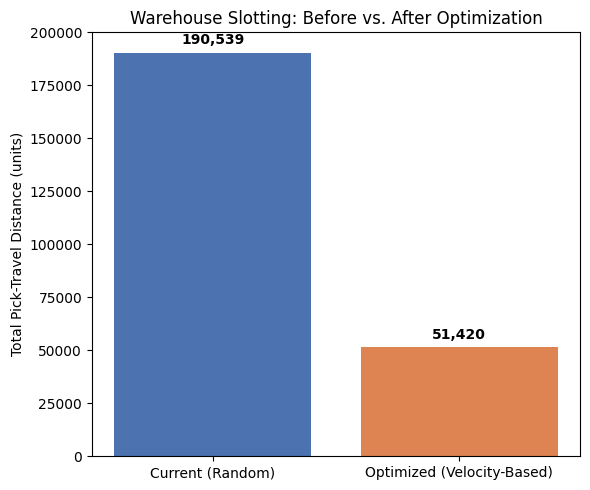

In [14]:
import matplotlib.pyplot as plt

labels = ["Current (Random)", "Optimized (Velocity-Based)"]
values = [current_total_travel, optimized_total_travel]

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, values, color=["#4C72B0", "#DD8452"])
plt.ylabel("Total Pick-Travel Distance (units)")
plt.title("Warehouse Slotting: Before vs. After Optimization")
for bar, v in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, v + max(values)*0.02, f"{v:,.0f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("before_after_travel_distance.png", dpi=150)
plt.show()

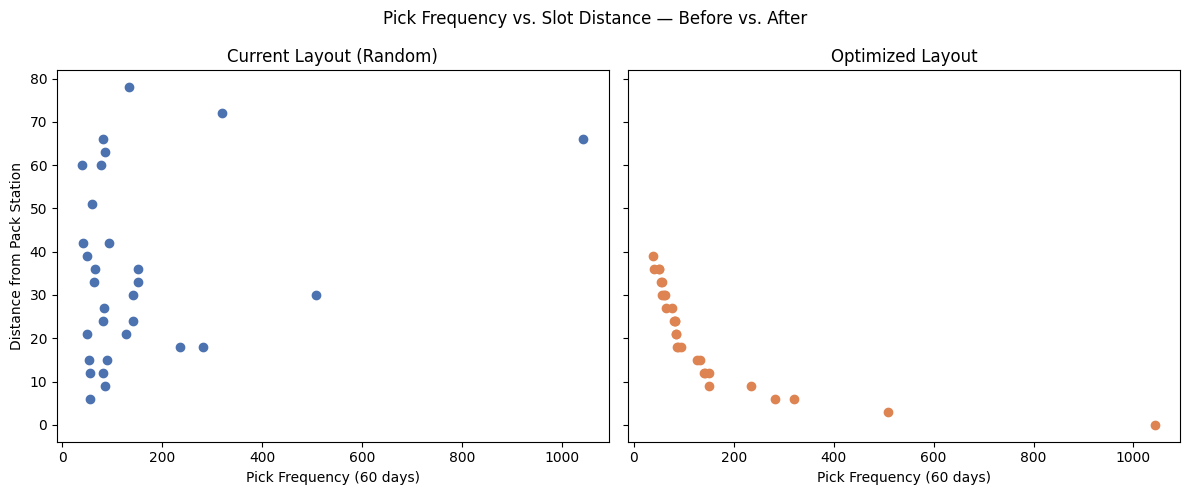

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].scatter(merged_sorted["Pick_Frequency_60Days"], merged_sorted["Distance_From_Pack_Station"], color="#4C72B0")
axes[0].set_title("Current Layout (Random)")
axes[0].set_xlabel("Pick Frequency (60 days)")
axes[0].set_ylabel("Distance from Pack Station")

axes[1].scatter(merged_sorted["Pick_Frequency_60Days"], merged_sorted["Optimized_Distance"], color="#DD8452")
axes[1].set_title("Optimized Layout")
axes[1].set_xlabel("Pick Frequency (60 days)")

plt.suptitle("Pick Frequency vs. Slot Distance — Before vs. After")
plt.tight_layout()
plt.savefig("scatter_before_after.png", dpi=150)
plt.show()

## Result

Total pick-travel distance dropped from **190,539** to **51,420** — a **~73% reduction** under this modeled scenario. This compares a fully random baseline layout to a fully velocity-optimized one; a real warehouse would likely realize a portion of this gain depending on implementation constraints (partial re-slotting, product size/weight limits, operational disruption). The exercise demonstrates the scale of value that ABC-based slotting can unlock.